## Validate NSFG data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

from nsfg.paths import raw, interim
import numpy as np
import seaborn as sns

import math

import matplotlib.pyplot as plt

from empiricaldist import Cdf

from nsfg import marriage

from nsfg.marriage import value_counts, decorate

In [3]:
# Make the figures smaller to save some screen real estate.
# The figures generated for the book have DPI 400, so scaling
# them by a factor of 4 restores them to the size in the notebooks.
plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [6, 3.5]

## Cycle 3

Note: Early cycles of the NSFG oversampled married women, so it's pretty important to correct for stratified sampling!

In [4]:
resp3 = marriage.read_fem_resp_1982()
marriage.validate_1982(resp3)
resp3.shape

(7969, 35)

In [5]:
value_counts(resp3["bdegree"])

bdegree
False    7089
True      880
Name: count, dtype: int64

In [6]:
value_counts(resp3["fmarital"])

fmarital
1    3551
2      79
3     587
4     434
5    3318
Name: count, dtype: int64

In [7]:
value_counts(resp3["rwant"])

rwant
1    5053
5    2916
Name: count, dtype: int64

<Axes: xlabel='ager'>

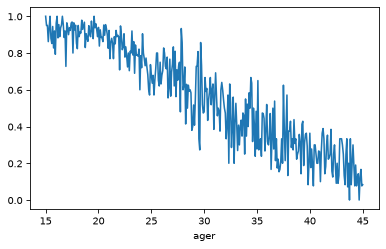

In [8]:
resp3["want_yes"] = resp3["rwant"] == 1
resp3.groupby("ager")["want_yes"].mean().plot()

In [9]:
# value_counts(resp3['nchildhh'])

In [10]:
value_counts(resp3["intent"])

intent
1    3937
2    3673
3     359
Name: count, dtype: int64

In [11]:
value_counts(resp3["addexp"])

addexp
0.0    3566
0.5      63
1.0    1393
1.5     197
2.0    1579
2.5     229
3.0     534
3.5      78
4.0     221
4.5      14
5.0      48
5.5      10
6.0      16
6.5       1
7.0       4
8.0       9
9.0       7
Name: count, dtype: int64

In [12]:
value_counts(resp3["rmarital"])

rmarital
1    3551
2     246
3      75
4     526
5     423
6    3148
Name: count, dtype: int64

In [13]:
resp3["marend01"].describe()

count    1635.000000
mean        1.386544
std         0.618812
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: marend01, dtype: float64

In [14]:
value_counts(resp3["fmarno"])

fmarno
0.0    3318
1.0    3953
2.0     612
3.0      77
4.0       5
5.0       2
8.0       2
Name: count, dtype: int64

In [15]:
resp3.fmarno.value_counts().sort_index()

fmarno
0.0    3318
1.0    3953
2.0     612
3.0      77
4.0       5
5.0       2
8.0       2
Name: count, dtype: int64

In [16]:
resp3.widowed.value_counts()

widowed
False    7850
True      119
Name: count, dtype: int64

In [17]:
sum(resp3.cmdivorcx.isnull()), 6841 + 29 + 5 + 56

(6932, 6931)

In [18]:
sum((resp3.cmdivorcx >= 400) & (resp3.cmdivorcx <= 948)), 583 + 128

(710, 711)

In [19]:
sum((resp3.cmdivorcx >= 949) & (resp3.cmdivorcx <= 1000)), 311 + 16

(327, 327)

In [20]:
sum(resp3.cmstphsbx.isnull()), 7571 + 1 + 6 + 31

(7609, 7609)

In [21]:
sum((resp3.cmstphsbx >= 400) & (resp3.cmstphsbx <= 948)), 125 + 33

(158, 158)

In [22]:
sum((resp3.cmstphsbx >= 949) & (resp3.cmstphsbx <= 1000)), 197 + 5

(202, 202)

In [23]:
sum(resp3.divorced)

1122

In [24]:
sum(~resp3.cmstphsbx.isnull())

360

In [25]:
sum(~resp3.cmdivorcx.isnull())

1037

## Cycle 4

Validating the 1988 data:

In [26]:
resp4 = marriage.read_fem_resp_1988()
marriage.validate_1988(resp4)
resp4.shape

(8450, 36)

In [27]:
value_counts(resp4["bdegree"])

bdegree
False    7095
True     1355
Name: count, dtype: int64

In [28]:
value_counts(resp4["fmarital"])

fmarital
1    4031
2      68
3     802
4     389
5    3160
Name: count, dtype: int64

In [29]:
value_counts(resp4["rwant"])

rwant
1    4611
5    3839
Name: count, dtype: int64

<Axes: xlabel='ager'>

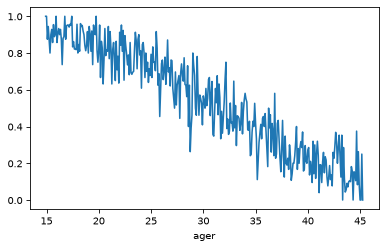

In [30]:
resp4["want_yes"] = resp4["rwant"] == 1
resp4.groupby("ager")["want_yes"].mean().plot()

In [31]:
# value_counts(resp4['nchildhh'])

In [32]:
value_counts(resp4["intent"])

intent
1    3354
2    4665
3     386
4      45
Name: count, dtype: int64

In [33]:
value_counts(resp4["addexp"])

addexp
0.0     4529
0.5       75
1.0     1311
1.5      222
2.0     1452
2.5      183
3.0      425
3.5       39
4.0      151
4.5        5
5.0       32
5.5        4
6.0       10
6.5        3
7.0        3
8.0        5
12.0       1
Name: count, dtype: int64

In [34]:
value_counts(resp4["rmarital"])

rmarital
1    4031
2     412
3      59
4     687
5     344
6    2917
Name: count, dtype: int64

In [35]:
value_counts(resp4["marend01"])

marend01
1.0    1553
2.0     330
3.0     108
NaN    6459
Name: count, dtype: int64

In [36]:
resp4.fmarno.describe()

count    8450.000000
mean        0.761183
std         0.711908
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: fmarno, dtype: float64

In [37]:
resp4.fmarno.value_counts().sort_index()

fmarno
0    3160
1    4325
2     829
3     108
4      15
5      13
Name: count, dtype: int64

In [38]:
resp4.evrmarry.value_counts().sort_index()

evrmarry
False    3160
True     5290
Name: count, dtype: int64

In [39]:
resp4.separated.value_counts().sort_index()

separated
False    8120
True      330
Name: count, dtype: int64

In [40]:
resp4.head()

,finalwgt,ageint,currentcm,firstcm,cmintvw,cmbirth,marend01,cmdivorcx,cmstphsbx,fmarno,...,stillma,cycle,agemarry,ager,missing,year,age_index,agemarry_index,birth_index,want_yes
0,713792,28,NaN,NaN,1061,723,NaN,NaN,NaN,0,...,False,4,NaN,28.166667,False,60,28.0,NaN,60,True
1,367022,37,NaN,NaN,1059,614,NaN,NaN,NaN,0,...,False,4,NaN,37.083333,False,51,37.0,NaN,50,True
2,975924,21,NaN,NaN,1057,796,NaN,NaN,NaN,0,...,False,4,NaN,21.750000,False,66,21.0,NaN,60,True
3,587796,39,NaN,838.0,1057,581,1.0,943.0,NaN,1,...,False,4,21.416667,39.666667,False,48,39.0,21.0,40,False
4,719633,31,974.0,882.0,1062,683,1.0,930.0,NaN,2,...,False,4,16.583333,31.583333,False,56,31.0,16.0,50,True


In [41]:
sum(resp4.cmdivorcx.isnull()), 6897 + 77

(6974, 6974)

In [42]:
sum((resp4.cmdivorcx >= 685) & (resp4.cmdivorcx <= 1008)), 903 + 152

(1055, 1055)

In [43]:
sum((resp4.cmdivorcx >= 1009) & (resp4.cmdivorcx <= 1064)), 399 + 22

(421, 421)

In [44]:
sum(resp4.cmstphsbx.isnull()), 8113 + 29

(8142, 8142)

In [45]:
sum((resp4.cmstphsbx >= 685) & (resp4.cmstphsbx <= 1008)), 75 + 31

(106, 106)

In [46]:
sum((resp4.cmstphsbx >= 1009) & (resp4.cmstphsbx <= 1064)), 193 + 9

(202, 202)

In [47]:
sum(resp4.divorced)

1553

In [48]:
sum(~resp4.cmstphsbx.isnull())

308

In [49]:
sum(~resp4.cmdivorcx.isnull())

1476

## Cycle 5

Validating the 1995 data:

In [50]:
resp5 = marriage.read_fem_resp_1995()
marriage.validate_1995(resp5)
resp5.shape

(10847, 35)

In [51]:
value_counts(resp5['bdegree'])

bdegree
False    8812
True     2035
Name: count, dtype: int64

In [52]:
# value_counts(resp5['rwant'])

In [53]:
# value_counts(resp5['nchildhh'])

In [54]:
value_counts(resp5["intent"])

intent
1    4192
2    5924
3     597
4     134
Name: count, dtype: int64

In [55]:
value_counts(resp5["addexp"])

addexp
0.0     5791
0.5      132
1.0     1694
1.5      376
2.0     1649
2.5      300
3.0      538
3.5      104
4.0      168
4.5       20
5.0       40
5.5        2
6.0       17
6.5        4
7.0        4
7.5        1
8.0        4
8.5        1
9.0        1
10.0       1
Name: count, dtype: int64

In [56]:
value_counts(resp5["rmarital"])

rmarital
1    5291
2     772
3      77
4     769
5     407
6    3531
Name: count, dtype: int64

In [57]:
value_counts(resp5["fmarno"])

fmarno
0    4003
1    5562
2    1077
3     174
4      26
5       5
Name: count, dtype: int64

In [58]:
value_counts(resp5["marend01"])

marend01
1.0    2073
2.0     354
3.0     110
NaN    8310
Name: count, dtype: int64

In [59]:
resp5.head()

,cmintvw,timesmar,cmmarrhx,cmbirth,finalwgt,marend01,cmdivorcx,cmstphsbx,marstat,fmarno,...,stillma,rwant,cycle,agemarry,ager,missing,year,age_index,agemarry_index,birth_index
0,1149,NaN,NaN,837,6776.3796,NaN,NaN,NaN,5,0,...,False,NaN,5,NaN,26.000000,False,69,26.0,NaN,60
1,1142,1.0,1024.0,781,841.8221,2.0,NaN,NaN,4,1,...,False,NaN,5,20.250000,30.083333,False,65,30.0,20.0,60
2,1145,NaN,NaN,907,3617.3637,NaN,NaN,NaN,5,0,...,False,NaN,5,NaN,19.833333,False,75,19.0,NaN,70
3,1145,1.0,1133.0,771,10788.1271,2.0,NaN,NaN,4,1,...,False,NaN,5,30.166667,31.166667,False,64,31.0,30.0,60
4,1144,NaN,NaN,927,5359.4150,NaN,NaN,NaN,5,0,...,False,NaN,5,NaN,18.083333,False,77,18.0,NaN,70


In [60]:
sum(resp5.cmdivorcx.isnull()), 9601 + 1 + 1 + 22

(9625, 9625)

In [61]:
sum((resp5.cmdivorcx >= 780) & (resp5.cmdivorcx <= 1092)), 1116

(1116, 1116)

In [62]:
sum((resp5.cmdivorcx >= 1093) & (resp5.cmdivorcx <= 1150)), 106

(106, 106)

In [63]:
sum(resp5.cmstphsbx.isnull()), 9601 + 1 + 15

(9617, 9617)

In [64]:
sum((resp5.cmstphsbx >= 780) & (resp5.cmstphsbx <= 1092)), 1167

(1167, 1167)

In [65]:
sum((resp5.cmstphsbx >= 1093) & (resp5.cmstphsbx <= 1150)), 63

(63, 63)

In [66]:
resp5.marend01.value_counts().sort_index()

marend01
1.0    2073
2.0     354
3.0     110
Name: count, dtype: int64

In [67]:
sum(resp5.divorced)

2073

In [68]:
sum(~resp5.cmstphsbx.isnull())

1230

In [69]:
sum(~resp5.cmdivorcx.isnull())

1222

In [70]:
sum((resp5.marend01 == 2) & (resp5.cmdivorcx.isnull()))

354

In [71]:
sum((resp5.marend01 == 3) & (resp5.cmdivorcx.isnull()))

110

In [72]:
sum((~resp5.divorced) & (~resp5.cmstphsbx.isnull()))

0

In [73]:
resp5.marstat.value_counts().sort_index()

marstat
1    5291
2      93
3    1008
4     452
5    4003
Name: count, dtype: int64

In [74]:
sum((resp5.marstat == 4) & (~resp5.divorced))  # separated and not divorced

360

In [75]:
sum((resp5.marstat == 4) & (~resp5.divorced) & (~resp5.cmstphsbx.isnull()))

0

## Cycle 6

Validating the 2002 data:

In [76]:
resp6 = marriage.read_fem_resp_2002()
marriage.validate_2002(resp6)
resp6.shape

(7643, 39)

In [77]:
value_counts(resp6["bdegree"])

bdegree
False    6051
True     1592
Name: count, dtype: int64

In [78]:
value_counts(resp6["fmarital"])

fmarital
1    3080
2      51
3     686
4     309
5    3517
Name: count, dtype: int64

In [79]:
value_counts(resp6["hieduc"])

hieduc
1     1671
2       32
4     2171
5     1624
7      553
8     1171
9      295
10      92
11      34
Name: count, dtype: int64

In [80]:
# value_counts(resp6['nchildhh'])

In [81]:
value_counts(resp6["intent"])

intent
1    3628
2    3900
3     115
Name: count, dtype: int64

In [82]:
value_counts(resp6["addexp"])

addexp
0.0     3739
0.5       27
1.0     1443
1.5       26
2.0     1585
2.5        7
3.0      516
3.5        2
4.0      207
5.0       54
6.0       18
7.0        6
9.0        2
10.0       5
11.0       2
12.0       1
14.0       1
15.0       1
33.0       1
Name: count, dtype: int64

In [83]:
value_counts(resp6["rmarital"])

rmarital
1    3080
2     732
3      49
4     557
5     279
6    2946
Name: count, dtype: int64

In [84]:
resp6.head()

,caseid,cmbirth,evrmarry,havedeg,degrees,cmmarrhx,cmdivorcx,rwant,fmarital,hieduc,...,widowed,stillma,cycle,agemarry,ager,missing,year,age_index,agemarry_index,birth_index
0,2298,902,False,NaN,NaN,NaN,NaN,5.0,5,1,...,False,False,6,NaN,27.666667,False,75,27.0,NaN,70
1,5012,718,True,5.0,NaN,974.0,1077.0,5.0,1,5,...,False,False,6,21.333333,42.916667,False,59,42.0,21.0,50
2,11586,708,True,NaN,NaN,910.0,938.0,5.0,3,4,...,False,False,6,16.833333,43.833333,False,58,43.0,16.0,50
3,6794,1042,False,NaN,NaN,NaN,NaN,1.0,5,1,...,False,False,6,NaN,16.000000,False,86,16.0,NaN,80
4,616,991,False,NaN,NaN,NaN,NaN,1.0,5,1,...,False,False,6,NaN,20.166667,False,82,20.0,NaN,80


In [85]:
sum(resp6.cmdivorcx.isnull()), 6639 + 2 + 20

(6661, 6661)

In [86]:
sum((resp6.cmdivorcx >= 301) & (resp6.cmdivorcx <= 1164)), 607

(607, 607)

In [87]:
sum((resp6.cmdivorcx >= 1165) & (resp6.cmdivorcx <= 1239)), 375

(375, 375)

In [88]:
resp6.marend01.value_counts().sort_index()

marend01
1.0    1232
2.0     260
3.0      58
Name: count, dtype: int64

In [89]:
sum(resp6.divorced), sum(resp6.loc[resp6.divorced, "mar1diss"].isnull())

(1232, 0)

In [90]:
sum(resp6.separated), sum(resp6.loc[resp6.separated, "mar1diss"].isnull())

(260, 0)

In [91]:
sum(resp6.widowed), sum(resp6.loc[resp6.widowed, "mar1diss"].isnull())

(58, 0)

In [92]:
sum(resp6.stillma), sum(resp6.loc[resp6.stillma, "mar1diss"].isnull())

(2576, 0)

In [93]:
sum(resp6.evrmarry), 1232 + 260 + 58 + 2576

(4126, 4126)

## Cycle 7

Validating the 2010 data:

In [94]:
resp7 = marriage.read_fem_resp_2010()
marriage.validate_2010(resp7)
resp7.shape

(12279, 39)

In [95]:
value_counts(resp7["fmarital"])

fmarital
1    3971
2      57
3    1009
4     497
5    6745
Name: count, dtype: int64

In [96]:
value_counts(resp7["bdegree"])

bdegree
False    9734
True     2545
Name: count, dtype: int64

In [97]:
value_counts(resp7["hieduc"])

hieduc
1     3216
2      197
4     2982
5     2472
7      867
8     1853
9      543
10      87
11      62
Name: count, dtype: int64

In [98]:
value_counts(resp7["nchildhh"])

nchildhh
0    6155
1    2296
2    2284
3    1544
Name: count, dtype: int64

In [99]:
value_counts(resp7["intent"])

intent
1    6320
2    5780
3     179
Name: count, dtype: int64

In [100]:
value_counts(resp7["addexp"])

addexp
0.0     5524
0.5       46
1.0     2342
1.5       56
2.0     2732
2.5       15
3.0     1030
3.5        7
4.0      367
4.5        1
5.0       84
5.5        1
6.0       46
7.0        4
8.0        8
9.0        5
10.0       4
11.0       1
12.0       2
22.0       1
23.0       2
33.0       1
Name: count, dtype: int64

In [101]:
sum(resp7.cmdivorcx.isnull()), 10705 + 1 + 19

(10730, 10725)

In [102]:
sum((resp7.cmdivorcx >= 522) & (resp7.cmdivorcx <= 1278)), 1286

(1281, 1286)

In [103]:
sum((resp7.cmdivorcx >= 1279) & (resp7.cmdivorcx <= 1290)), 106

(106, 106)

In [104]:
sum((resp7.cmdivorcx >= 1291) & (resp7.cmdivorcx <= 1308)), 112

(112, 112)

In [105]:
sum((resp7.cmdivorcx >= 1309) & (resp7.cmdivorcx <= 1326)), 50

(50, 50)

In [106]:
resp7.marend01.value_counts().sort_index()

marend01
1.0    1574
2.0     405
3.0      68
Name: count, dtype: int64

In [107]:
sum(resp7.divorced), sum(resp7.loc[resp7.divorced, "mar1diss"].isnull())

(1574, 0)

In [108]:
sum(resp7.separated), sum(resp7.loc[resp7.separated, "mar1diss"].isnull())

(405, 0)

In [109]:
sum(resp7.widowed), sum(resp7.loc[resp7.widowed, "mar1diss"].isnull())

(68, 0)

In [110]:
sum(resp7.stillma), sum(resp7.loc[resp7.stillma, "mar1diss"].isnull())

(3487, 0)

In [111]:
sum(resp7.evrmarry), 1574 + 405 + 68 + 3487

(5534, 5534)

## Cycle 8

Validating the 2013 data

In [112]:
resp8 = marriage.read_fem_resp_2013()
marriage.validate_2013(resp8)
resp8.shape

(5601, 38)

In [113]:
value_counts(resp8["bdegree"])

bdegree
False    4436
True     1165
Name: count, dtype: int64

In [114]:
value_counts(resp8["fmarital"])

fmarital
1    1711
2      25
3     465
4     251
5    3149
Name: count, dtype: int64

In [115]:
value_counts(resp8["hieduc"])

hieduc
1     1235
2       34
4     1488
5     1245
7      434
8      776
9      314
10      36
11      39
Name: count, dtype: int64

In [116]:
value_counts(resp8["nchildhh"])

nchildhh
0    2691
1    1112
2    1052
3     746
Name: count, dtype: int64

In [117]:
value_counts(resp8["intent"])

intent
1    2928
2    2605
3      68
Name: count, dtype: int64

In [118]:
value_counts(resp8["addexp"])

addexp
0.0     2494
0.5       21
1.0     1131
1.5       22
2.0     1257
2.5        5
3.0      443
3.5        2
4.0      161
5.0       43
6.0       17
7.0        2
8.0        1
10.0       1
11.0       1
Name: count, dtype: int64

In [119]:
sum(resp8.cmdivorcx.isnull()), 4851 + 2 + 24

(4877, 4877)

In [120]:
sum((resp8.cmdivorcx >= 380) & (resp8.cmdivorcx <= 1340)), 658

(658, 658)

In [121]:
sum((resp8.cmdivorcx >= 1341) & (resp8.cmdivorcx <= 1352)), 48

(48, 48)

In [122]:
sum((resp8.cmdivorcx >= 1353) & (resp8.cmdivorcx <= 1365)), 18

(18, 18)

In [123]:
resp8.marend01.value_counts().sort_index()

marend01
1.0    755
2.0    214
3.0     26
Name: count, dtype: int64

In [124]:
sum(resp8.divorced), sum(resp8.loc[resp8.divorced, "mar1diss"].isnull())

(755, 0)

In [125]:
sum(resp8.separated), sum(resp8.loc[resp8.separated, "mar1diss"].isnull())

(214, 0)

In [126]:
sum(resp8.widowed), sum(resp8.loc[resp8.widowed, "mar1diss"].isnull())

(26, 0)

In [127]:
sum(resp8.stillma), sum(resp8.loc[resp8.stillma, "mar1diss"].isnull())

(1457, 0)

In [128]:
sum(resp8.evrmarry), 755 + 214 + 26 + 1457

(2452, 2452)

## Cycle 9

Validating the 2015 data

In [129]:
from nsfg.marriage import read_fem_resp_2015

resp9 = read_fem_resp_2015()
marriage.validate_2015(resp9)
resp9.shape

(5699, 38)

In [130]:
value_counts(resp9["bdegree"])

bdegree
False    4370
True     1329
Name: count, dtype: int64

In [131]:
value_counts(resp9["fmarital"])

fmarital
1    1699
2      23
3     471
4     208
5    3298
Name: count, dtype: int64

In [132]:
value_counts(resp9["hieduc"])

hieduc
1     1240
2       33
4     1428
5     1229
7      440
8      853
9      373
10      50
11      53
Name: count, dtype: int64

In [133]:
value_counts(resp9["nchildhh"])

nchildhh
0    2870
1    1116
2     994
3     719
Name: count, dtype: int64

In [134]:
value_counts(resp9["intent"])

intent
1    2935
2    2680
3      84
Name: count, dtype: int64

In [135]:
value_counts(resp9["addexp"])

addexp
0.0     2550
0.5       23
1.0     1168
1.5       21
2.0     1313
2.5        8
3.0      421
4.0      137
5.0       38
6.0        9
7.0        3
8.0        1
10.0       3
12.0       2
13.0       1
22.0       1
Name: count, dtype: int64

In [136]:
sum(resp9.cmdivorcx.isnull()), 4946 + 3 + 18

(4967, 4967)

In [137]:
sum((resp9.cmdivorcx >= 378) & (resp9.cmdivorcx <= 1340)), 563

(563, 563)

In [138]:
sum((resp9.cmdivorcx >= 1341) & (resp9.cmdivorcx <= 1352)), 56

(56, 56)

In [139]:
sum((resp9.cmdivorcx >= 1353) & (resp9.cmdivorcx <= 1364)), 48

(48, 48)

In [140]:
sum((resp9.cmdivorcx >= 1365) & (resp9.cmdivorcx <= 1376)), 46

(46, 46)

In [141]:
sum((resp9.cmdivorcx >= 1377) & (resp9.cmdivorcx <= 1389)), 19

(19, 19)

In [142]:
resp9.marend01.value_counts().sort_index()

marend01
1.0    756
2.0    169
3.0     28
Name: count, dtype: int64

In [143]:
sum(resp9.divorced), sum(resp9.loc[resp9.divorced, "mar1diss"].isnull())

(756, 0)

In [144]:
sum(resp9.separated), sum(resp9.loc[resp9.separated, "mar1diss"].isnull())

(169, 0)

In [145]:
sum(resp9.widowed), sum(resp9.loc[resp9.widowed, "mar1diss"].isnull())

(28, 0)

In [146]:
sum(resp9.stillma), sum(resp9.loc[resp9.stillma, "mar1diss"].isnull())

(1448, 0)

In [147]:
sum(resp9.evrmarry), 756 + 169 + 28 + 1448

(2401, 2401)

## Cycle 10

Validating 2017 data

In [148]:
resp10 = marriage.read_fem_resp_2017()
marriage.validate_2017(resp10)

In [149]:
value_counts(resp10["bdegree"])

bdegree
False    4101
True     1453
Name: count, dtype: int64

In [150]:
value_counts(resp10["fmarital"])

fmarital
1    1828
2      44
3     509
4     201
5    2972
Name: count, dtype: int64

In [151]:
value_counts(resp10["hieduc"])

hieduc
1     1123
2       25
4     1419
5     1102
7      432
8      943
9      409
10      49
11      52
Name: count, dtype: int64

In [152]:
value_counts(resp10["nchildhh"])

nchildhh
0    2857
1    1080
2    1018
3     599
Name: count, dtype: int64

In [153]:
value_counts(resp10["intent"])

intent
1    2514
2    2966
3      74
Name: count, dtype: int64

In [154]:
value_counts(resp10["addexp"])

addexp
0.0     2865
0.5       23
1.0     1003
1.5       18
2.0     1060
2.5        4
3.0      381
4.0      136
5.0       40
6.0       13
7.0        3
8.0        1
9.0        2
10.0       1
11.0       2
14.0       1
33.0       1
Name: count, dtype: int64

In [155]:
value_counts(resp10["marend01"])

marend01
1.0     818
2.0     166
3.0      55
NaN    4515
Name: count, dtype: int64

In [156]:
resp10["cmdivorcx"].describe()

count     818.000000
mean     1255.334963
std        93.168345
min       978.000000
25%      1182.000000
50%      1278.000000
75%      1338.000000
max      1410.000000
Name: cmdivorcx, dtype: float64

In [157]:
resp10.shape

(5554, 37)

In [158]:
sum(resp10.evrmarry)

2582

In [159]:
resp10.agemarry.value_counts().max()

np.int64(29)

In [160]:
resp10.head()

,caseid,evrmarry,hyst,tubs,rwant,ager,fmarital,rmarital,hieduc,nchildhh,...,cmbirth,cmmarrhx,cmdivorcx,cycle,agemarry,missing,year,age_index,agemarry_index,birth_index
0,70623,False,5,5,1.0,16,5,6,1,0,...,1192,NaN,NaN,10,NaN,False,99,16.0,NaN,90
1,70624,True,5,5,1.0,40,3,4,8,0,...,908,1254.0,1290.0,10,28.833333,False,75,40.0,28.0,70
2,70625,False,5,5,5.0,15,5,6,1,0,...,1216,NaN,NaN,10,NaN,False,101,15.0,NaN,100
3,70627,True,5,5,5.0,35,1,1,8,2,...,968,1302.0,NaN,10,27.833333,False,80,35.0,27.0,80
4,70628,True,5,1,1.0,28,1,1,7,3,...,1067,1326.0,NaN,10,21.583333,False,88,28.0,21.0,80


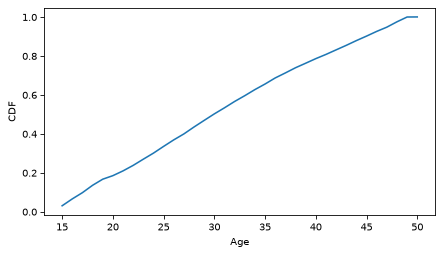

In [161]:
Cdf.from_seq(resp10.ager).plot()
decorate(xlabel="Age", ylabel="CDF")

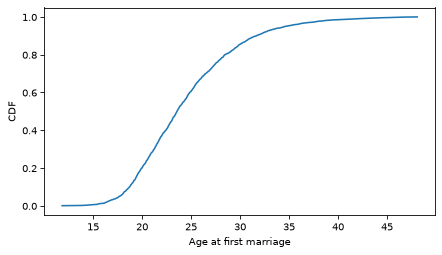

In [162]:
Cdf.from_seq(resp10.agemarry).plot()
decorate(xlabel="Age at first marriage", ylabel="CDF")

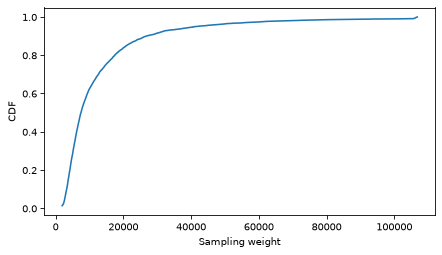

In [163]:
Cdf.from_seq(resp10.finalwgt).plot()
decorate(xlabel="Sampling weight", ylabel="CDF")

## Cycle 11

Validating 2019 data

In [164]:
from nsfg.marriage import read_fem_resp_2019

resp11 = read_fem_resp_2019()
marriage.validate_2019(resp11)
resp11.shape

(6141, 37)

In [165]:
value_counts(resp11["bdegree"])

bdegree
False    4521
True     1620
Name: count, dtype: int64

In [166]:
value_counts(resp11["fmarital"])

fmarital
1    1913
2      40
3     550
4     219
5    3419
Name: count, dtype: int64

In [167]:
value_counts(resp11["hieduc"])

hieduc
1     1137
2       31
4     1614
5     1227
7      512
8     1072
9      445
10      60
11      43
Name: count, dtype: int64

In [168]:
value_counts(resp11["nchildhh"])

nchildhh
0    3300
1    1117
2    1066
3     658
Name: count, dtype: int64

In [169]:
value_counts(resp11["intent"])

intent
1    2720
2    3324
3      97
Name: count, dtype: int64

In [170]:
value_counts(resp11["addexp"])

addexp
0.0     3229
0.5       23
1.0     1069
1.5       35
2.0     1149
2.5        6
3.0      446
3.5        1
4.0      134
5.0       31
6.0       10
6.5        2
7.0        3
10.0       3
Name: count, dtype: int64

In [171]:
value_counts(resp11["marend01"])

marend01
1.0     873
2.0     177
3.0      45
NaN    5046
Name: count, dtype: int64

In [172]:
resp11["cmdivorcx"].describe()

count     873.000000
mean     1281.587629
std        88.792793
min      1002.000000
25%      1218.000000
50%      1290.000000
75%      1350.000000
max      1434.000000
Name: cmdivorcx, dtype: float64

In [173]:
sum(resp11.evrmarry)

2722

In [174]:
resp11.agemarry.value_counts().max()

np.int64(29)

In [175]:
resp11.head()

,caseid,evrmarry,hyst,tubs,rwant,ager,fmarital,rmarital,hieduc,nchildhh,...,cmbirth,cmmarrhx,cmdivorcx,cycle,agemarry,missing,year,age_index,agemarry_index,birth_index
0,80716,False,5,5,1.0,35,5,6,8,0,...,1004,NaN,NaN,11,NaN,False,83,35.0,NaN,80
1,80718,False,5,5,1.0,30,5,6,8,0,...,1047,NaN,NaN,11,NaN,False,87,30.0,NaN,80
2,80719,False,5,1,5.0,30,5,6,4,3,...,1059,NaN,NaN,11,NaN,False,88,30.0,NaN,80
3,80720,True,5,5,1.0,32,1,1,8,2,...,1043,1326.0,NaN,11,23.583333,False,86,32.0,23.0,80
4,80723,True,5,1,5.0,27,3,4,4,3,...,1092,1338.0,1398.0,11,20.500000,False,90,27.0,20.0,90


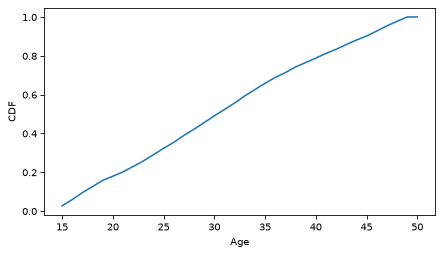

In [176]:
Cdf.from_seq(resp11.ager).plot()
decorate(xlabel="Age", ylabel="CDF")

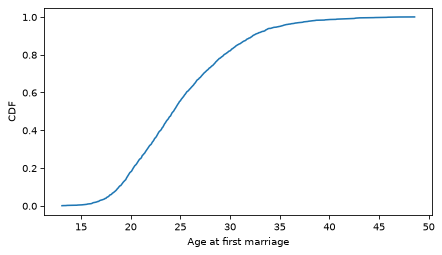

In [177]:
Cdf.from_seq(resp11.agemarry).plot()
decorate(xlabel="Age at first marriage", ylabel="CDF")

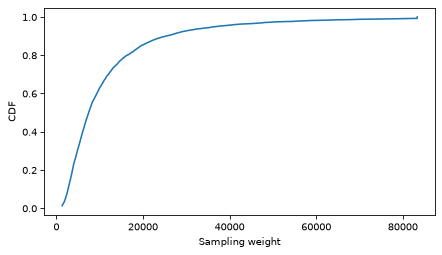

In [178]:
Cdf.from_seq(resp11.finalwgt).plot()
decorate(xlabel="Sampling weight", ylabel="CDF")

In [179]:
value_counts(resp11["intent"])

intent
1    2720
2    3324
3      97
Name: count, dtype: int64

In [180]:
value_counts(resp11["addexp"])

addexp
0.0     3229
0.5       23
1.0     1069
1.5       35
2.0     1149
2.5        6
3.0      446
3.5        1
4.0      134
5.0       31
6.0       10
6.5        2
7.0        3
10.0       3
Name: count, dtype: int64

## Cycle 12

Validating 2023 data

In [181]:
from nsfg.marriage import read_fem_resp_2023

resp12 = read_fem_resp_2023()
resp12.shape

(5586, 37)

In [182]:
value_counts(resp12["bdegree"])

bdegree
False    3343
True     2243
Name: count, dtype: int64

In [183]:
value_counts(resp12["fmarital"])

fmarital
1.0    2060
2.0      25
3.0     365
4.0     112
5.0    3024
Name: count, dtype: int64

In [184]:
value_counts(resp12["hieduc"])

hieduc
1.0      623
2.0      169
3.0      153
4.0      807
5.0      956
6.0      353
7.0      282
8.0     1267
9.0      752
10.0     135
11.0      89
Name: count, dtype: int64

In [185]:
for col in resp12.columns:
    if "baby" in col:
        print(col)

agebaby1


In [186]:
value_counts(resp12["parity"])

parity
0.0     2833
1.0      931
2.0     1009
3.0      488
4.0      202
5.0       65
6.0       31
7.0       12
8.0        5
9.0        6
11.0       2
12.0       2
Name: count, dtype: int64

In [187]:
value_counts(resp12["nchildhh"])

nchildhh
0.0    3227
1.0     947
2.0     914
3.0     498
Name: count, dtype: int64

In [188]:
value_counts(resp12["intent"])

intent
1.0    1888
2.0    3593
3.0      88
4.0      17
Name: count, dtype: int64

In [189]:
value_counts(resp12["addexp"])

addexp
0.0     3634
0.5       20
1.0      656
1.5       17
2.0      869
2.5        3
3.0      286
4.0       76
4.5        1
5.0       13
6.0        3
7.0        2
8.0        4
9.0        1
11.0       1
Name: count, dtype: int64

In [190]:
resp12["evrmarry"].value_counts()

evrmarry
False    3024
True     2562
Name: count, dtype: int64

In [191]:
resp12["marend01"].value_counts()

marend01
1.0    631
2.0     85
3.0     27
Name: count, dtype: int64

In [192]:
resp12["fmarno"].value_counts()

fmarno
0.0    3024
1.0    2237
2.0     274
3.0      45
4.0       4
5.0       2
Name: count, dtype: int64

In [193]:
resp12["fmarno"].value_counts()

fmarno
0.0    3024
1.0    2237
2.0     274
3.0      45
4.0       4
5.0       2
Name: count, dtype: int64

In [194]:
resp12["ager"].value_counts()

ager
32.0    227
33.0    217
30.0    206
31.0    198
35.0    190
38.0    189
37.0    189
29.0    183
41.0    181
34.0    180
39.0    180
36.0    180
40.0    178
27.0    176
18.0    170
19.0    162
28.0    160
43.0    152
42.0    152
25.0    147
45.0    145
17.0    142
49.0    140
47.0    138
26.0    137
48.0    135
44.0    135
46.0    134
15.0    132
20.0    127
24.0    126
22.0    124
16.0    124
23.0    116
21.0    113
50.0      1
Name: count, dtype: int64

In [195]:
resp12["mardat01"].value_counts()

mardat01
2016.0    145
2013.0    130
2014.0    127
2010.0    126
2012.0    125
2019.0    119
2008.0    116
2015.0    115
2017.0    114
2009.0    110
2020.0    110
2021.0    108
2007.0    104
2018.0     99
2011.0     90
2022.0     87
2006.0     82
2005.0     81
2004.0     67
2003.0     61
2001.0     58
2002.0     51
1999.0     51
2000.0     48
1998.0     42
1996.0     31
1997.0     30
1994.0     24
2023.0     22
1993.0     22
1995.0     20
1992.0     14
1991.0      9
1990.0      3
Name: count, dtype: int64

In [196]:
resp12["mardis01"].value_counts()

mardis01
2019.0    49
2018.0    47
2016.0    46
2011.0    36
2022.0    35
2020.0    34
2014.0    34
2009.0    34
2010.0    33
2012.0    32
2015.0    31
2021.0    30
2017.0    28
2013.0    27
2008.0    24
2004.0    23
2005.0    21
2001.0    20
2007.0    20
2000.0    19
2003.0    18
1999.0    16
2006.0    14
2023.0    11
1998.0    11
2002.0    11
1997.0    11
1996.0     8
1994.0     5
1993.0     4
1995.0     4
9997.0     4
1992.0     2
1990.0     1
Name: count, dtype: int64

In [197]:
value_counts(resp12["marend01"])

marend01
1.0     631
2.0      85
3.0      27
NaN    4843
Name: count, dtype: int64

In [198]:
resp12["cmdivorcx"].describe()

count      631.000000
mean      1788.123613
std       6598.278385
min       1086.000000
25%       1266.000000
50%       1350.000000
75%       1410.000000
max      97170.000000
Name: cmdivorcx, dtype: float64

In [199]:
sum(resp12.evrmarry)

2562

In [200]:
resp12.agemarry.value_counts().max()

np.int64(41)

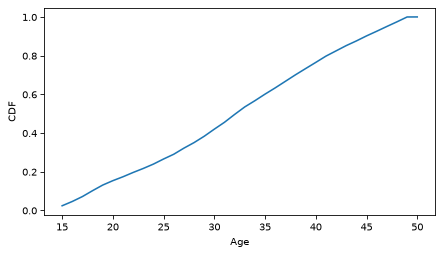

In [201]:
Cdf.from_seq(resp12.ager).plot()
decorate(xlabel="Age", ylabel="CDF")

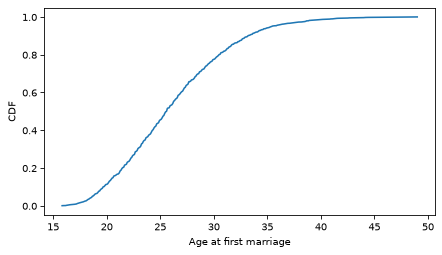

In [202]:
Cdf.from_seq(resp12.agemarry).plot()
decorate(xlabel="Age at first marriage", ylabel="CDF")

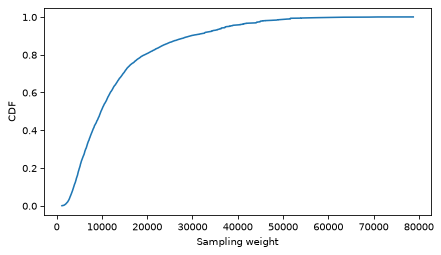

In [203]:
Cdf.from_seq(resp12.finalwgt).plot()
decorate(xlabel="Sampling weight", ylabel="CDF")

## Concatenate the data

Make a list of DataFrames, one for each cycle:

In [204]:
resps = [resp12, resp11, resp10, resp9, resp8, resp7, resp6, resp5, resp4, resp3]
# resps = [resp11]

Make a table showing the number of respondents in each cycle:

In [205]:
def SummarizeCycle(df):
    ages = df.ager.min(), df.ager.max()
    ages = np.array(ages)

    intvws = df.cmintvw.min(), df.cmintvw.max()
    intvws = np.array(intvws) / 12 + 1900

    births = df.cmbirth.min(), df.cmbirth.max()
    births = np.array(births) / 12 + 1900

    print("# & ", intvws.astype(int), "&", len(df), "&", births.astype(int), r"\\")


for resp in reversed(resps):
    SummarizeCycle(resp)

# &  [1982 1983] & 7969 & [1937 1968] \\
# &  [1988 1988] & 8450 & [1943 1973] \\
# &  [1995 1995] & 10847 & [1950 1980] \\
# &  [2002 2003] & 7643 & [1957 1988] \\
# &  [2006 2010] & 12279 & [1961 1995] \\
# &  [2011 2013] & 5601 & [1966 1998] \\
# &  [2013 2015] & 5699 & [1968 2000] \\
# &  [2015 2017] & 5554 & [1965 2002] \\
# &  [2017 2019] & 6141 & [1968 2004] \\
# &  [2022 2024] & 5586 & [1972 2008] \\


Check for missing values in `agemarry`:

In [206]:
def CheckAgeVars(df):
    print(sum(df[df.evrmarry].agemarry.isnull()))


for resp in resps:
    CheckAgeVars(resp)

21
0
0
11
17
16
37
0
22
0


Combine the DataFrames (but remember that this is not resampled properly):

In [207]:
df = pd.concat(resps, ignore_index=True, sort=False)
len(df)

75769

```
1 CURRENTLY MARRIED 3971
2 NOT MARRIED BUT LIVING WITH OPP SEX PARTNER 1451
3 WIDOWED 43
4 DIVORCED 786
5 SEPARATED FOR REASONS OF MARITAL DISCORD 431
6 NEVER BEEN MARRIED 5597
```

In [208]:
pd.crosstab(df["bdegree"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
bdegree,,,,,,,,,,
False,7089,7095,8812,6051,9734,4436,4370,4101,4521,3343
True,880,1355,2035,1592,2545,1165,1329,1453,1620,2243


In [209]:
pd.crosstab(df["fmarital"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
fmarital,,,,,,,,,,
1.0,3551,4031,5291,3080,3971,1711,1699,1828,1913,2060
2.0,79,68,93,51,57,25,23,44,40,25
3.0,587,802,1008,686,1009,465,471,509,550,365
4.0,434,389,452,309,497,251,208,201,219,112
5.0,3318,3160,4003,3517,6745,3149,3298,2972,3419,3024


In [210]:
pd.crosstab(df["strloper"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
strloper,,,,,,,,,,
1.0,1112,1636,0,1067,1609,733,692,748,805,478
2.0,391,404,0,213,205,93,92,169,182,120
3.0,301,502,0,308,466,182,152,186,219,277
4.0,34,46,0,31,45,17,22,26,27,54
5.0,6131,5862,0,6024,9954,4576,4741,4425,4908,4657
NaN,0,0,10847,0,0,0,0,0,0,0


In [211]:
pd.crosstab(df["tubs"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
tubs,,,,,,,,,,
1.0,0,0,0,1165,1650,747,703,782,838,499
5.0,0,0,0,6478,10629,4854,4996,4772,5303,5087
NaN,7969,8450,10847,0,0,0,0,0,0,0


In [212]:
pd.crosstab(df["hyst"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
hyst,,,,,,,,,,
1.0,0,0,0,282,341,166,164,260,280,181
5.0,0,0,0,7361,11938,5435,5535,5294,5861,5405
NaN,7969,8450,10847,0,0,0,0,0,0,0


In [213]:
pd.crosstab(df["anycoll"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
anycoll,,,,,,,,,,
False,5263,4999,6158,3874,6395,2757,2701,2567,2782,1752
True,2706,3451,4689,3769,5884,2844,2998,2987,3359,3834


In [214]:
pd.crosstab(df["educat"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
educat,,,,,,,,,,
0.0,4,3,0,0,0,0,0,0,0,0
1.0,2,1,0,0,0,0,0,0,0,0
2.0,2,12,0,0,0,0,0,0,0,0
3.0,6,9,0,0,0,0,0,0,0,0
4.0,16,6,0,0,0,0,0,0,0,0
5.0,14,12,0,0,0,0,0,0,0,0
6.0,40,48,0,0,0,0,0,0,0,0
7.0,67,73,0,0,0,0,0,0,0,0
8.0,237,246,0,0,0,0,0,0,0,0


In [215]:
pd.crosstab(df["hieduc"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
hieduc,,,,,,,,,,
1.0,0,0,2251,1671,3216,1235,1240,1123,1137,623
2.0,0,0,42,32,197,34,33,25,31,169
3.0,0,0,0,0,0,0,0,0,0,153
4.0,0,0,3865,2171,2982,1488,1428,1419,1614,807
5.0,0,0,2048,1624,2472,1245,1229,1102,1227,956
6.0,0,0,0,0,0,0,0,0,0,353
7.0,0,0,656,553,867,434,440,432,512,282
8.0,0,0,1553,1171,1853,776,853,943,1072,1267
9.0,0,0,349,295,543,314,373,409,445,752


In [216]:
pd.crosstab(df["addexp"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
addexp,,,,,,,,,,
0.0,3566,4529,5791,3739,5524,2494,2550,2865,3229,3634
0.5,63,75,132,27,46,21,23,23,23,20
1.0,1393,1311,1694,1443,2342,1131,1168,1003,1069,656
1.5,197,222,376,26,56,22,21,18,35,17
2.0,1579,1452,1649,1585,2732,1257,1313,1060,1149,869
2.5,229,183,300,7,15,5,8,4,6,3
3.0,534,425,538,516,1030,443,421,381,446,286
3.5,78,39,104,2,7,2,0,0,1,0
4.0,221,151,168,207,367,161,137,136,134,76


In [217]:
pd.crosstab(df["agebaby1"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
agebaby1,,,,,,,,,,
8.25,0,0,0,0,1,0,1,0,0,0
10.25,0,0,0,0,0,0,1,0,0,0
10.66,0,0,0,0,1,0,0,0,0,0
10.75,1,0,0,0,0,0,0,0,0,0
10.83,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
44.41,0,0,0,0,1,0,0,0,0,0
45.00,0,0,0,0,0,0,0,0,0,3
46.00,0,0,0,0,0,0,0,0,1,0


In [218]:
df.groupby("cycle")["agebaby1"].describe()

,count,mean,std,min,25%,50%,75%,max
cycle,,,,,,,,
3,4607.0,21.071450,4.001623,10.75,18.17,20.33,23.33,42.67
4,5328.0,21.927399,4.395177,11.92,18.73,21.08,24.67,41.08
5,6911.0,22.691519,4.897003,12.67,18.92,21.75,25.75,43.17
6,4413.0,23.084414,5.291378,10.83,18.91,21.91,26.58,43.00
7,6683.0,22.829473,5.259124,8.25,18.91,21.41,26.16,44.41
8,3141.0,22.828096,5.147017,11.50,18.91,21.58,26.08,42.66
9,3067.0,23.205214,5.411473,8.25,19.08,21.91,26.75,42.58
10,3150.0,23.149524,5.654287,12.00,19.00,22.00,27.00,44.00
11,3315.0,23.244646,5.612636,11.00,19.00,22.00,27.00,46.00


In [219]:
pd.crosstab(df["intent"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
intent,,,,,,,,,,
1.0,3937,3354,4192,3628,6320,2928,2935,2514,2720,1888
2.0,3673,4665,5924,3900,5780,2605,2680,2966,3324,3593
3.0,359,386,597,115,179,68,84,74,97,88
4.0,0,45,134,0,0,0,0,0,0,17


In [220]:
pd.crosstab(df["strloper"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
strloper,,,,,,,,,,
1.0,1112,1636,0,1067,1609,733,692,748,805,478
2.0,391,404,0,213,205,93,92,169,182,120
3.0,301,502,0,308,466,182,152,186,219,277
4.0,34,46,0,31,45,17,22,26,27,54
5.0,6131,5862,0,6024,9954,4576,4741,4425,4908,4657
NaN,0,0,10847,0,0,0,0,0,0,0


In [221]:
pd.crosstab(df["parity"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
parity,,,,,,,,,,
0.0,3356,3122,3936,3230,5596,2460,2632,2404,2826,2833
1.0,1448,1559,2072,1519,2214,1043,1040,1011,1039,931
2.0,1605,2109,2654,1603,2360,1100,1057,1159,1201,1009
3.0,895,1040,1418,828,1313,640,621,626,670,488
4.0,373,364,518,309,496,232,228,243,262,202
5.0,154,162,156,95,181,86,82,67,79,65
6.0,83,58,51,29,74,23,22,25,44,31
7.0,29,23,21,15,26,12,11,13,10,12
8.0,17,10,15,8,8,3,4,3,6,5


In [222]:
pd.crosstab(df["fmarno"], df["cycle"], dropna=False)

cycle,3,4,5,6,7,8,9,10,11,12
fmarno,,,,,,,,,,
0.0,3318,3160,4003,3517,6745,3149,3298,2972,3419,3024
1.0,3953,4325,5562,3436,4788,2076,2037,2156,2293,2237
2.0,612,829,1077,582,631,332,317,357,356,274
3.0,77,108,174,90,103,34,37,55,61,45
4.0,5,15,26,15,8,9,9,10,12,4
5.0,2,13,5,3,3,1,1,2,0,2
6.0,0,0,0,0,1,0,0,2,0,0
8.0,2,0,0,0,0,0,0,0,0,0


In [223]:
pd.crosstab(df["evrmarry"], df["cycle"])

cycle,3,4,5,6,7,8,9,10,11,12
evrmarry,,,,,,,,,,
False,3318,3160,4006,3517,6745,3149,3298,2972,3419,3024
True,4651,5290,6841,4126,5534,2452,2401,2582,2722,2562


In [224]:
pd.crosstab(df["marend01"], df["cycle"])

cycle,3,4,5,6,7,8,9,10,11,12
marend01,,,,,,,,,,
1.0,1122,1553,2073,1232,1574,755,756,818,873,631
2.0,394,330,354,260,405,214,169,166,177,85
3.0,119,108,110,58,68,26,28,55,45,27


In [225]:
df.groupby("cycle")["ager"].describe()

,count,mean,std,min,25%,50%,75%,max
cycle,,,,,,,,
3,7969.0,27.708454,8.181847,15.000000,20.250000,27.000000,34.000000,45.000000
4,8450.0,30.035089,8.130994,14.916667,23.416667,30.250000,36.666667,45.250000
5,10847.0,31.090686,8.303936,14.833333,24.333333,31.916667,38.000000,45.500000
6,7643.0,30.001592,8.433760,15.000000,22.833333,30.000000,37.166667,45.000000
7,12279.0,29.136622,8.451631,15.000000,21.916667,28.666667,36.166667,45.083333
8,5601.0,29.104133,8.375936,15.000000,21.916667,28.833333,35.916667,45.083333
9,5699.0,29.379423,8.405552,15.000000,22.416667,29.166667,36.083333,45.166667
10,5554.0,31.016745,9.886329,15.000000,23.000000,30.000000,39.000000,50.000000
11,6141.0,31.147044,9.749085,15.000000,23.000000,31.000000,39.000000,50.000000


In [226]:
df.groupby("cycle")["cmmarrhx"].describe()

,count,mean,std,min,25%,50%,75%,max
cycle,,,,,,,,
3,4651.0,857.943883,83.893561,626.0,800.00,863.0,927.0,997.0
4,5268.0,911.531131,84.646230,685.0,845.00,915.0,981.0,1062.0
5,6844.0,993.719608,85.862666,780.0,924.00,997.0,1066.0,1149.0
6,4089.0,1102.219124,84.454045,871.0,1042.00,1110.0,1173.0,1236.0
7,5520.0,1174.797826,82.526545,920.0,1115.75,1183.0,1243.0,1324.0
8,2435.0,1226.575359,78.826596,999.0,1175.00,1232.0,1291.0,1363.0
9,2390.0,1249.898745,78.903270,1026.0,1195.00,1256.0,1316.0,1388.0
10,2582.0,1246.838110,100.573347,966.0,1170.00,1254.0,1326.0,1410.0
11,2722.0,1273.238795,97.275836,990.0,1206.00,1290.0,1350.0,1434.0


In [227]:
df.groupby("cycle")["cmintvw"].describe()

,count,mean,std,min,25%,50%,75%,max
cycle,,,,,,,,
3,7969.0,994.452252,1.416700,992.0,993.0,994.0,995.0,1000.0
4,8450.0,1059.450888,1.548602,1057.0,1058.0,1059.0,1060.0,1064.0
5,10847.0,1143.968471,2.024495,1141.0,1142.0,1143.0,1145.0,1150.0
6,7643.0,1232.783200,2.978545,1225.0,1231.0,1233.0,1235.0,1239.0
7,12279.0,1302.753644,14.213140,1278.0,1290.0,1303.0,1315.0,1326.0
8,5601.0,1352.992144,6.762999,1341.0,1347.0,1353.0,1359.0,1365.0
9,5699.0,1377.168451,6.864101,1365.0,1372.0,1377.0,1383.0,1389.0
10,5554.0,1400.902413,6.971852,1389.0,1395.0,1401.0,1407.0,1413.0
11,6141.0,1424.813223,7.065362,1413.0,1419.0,1425.0,1431.0,1437.0


In [228]:
df.groupby("cycle")["cmbirth"].describe()

,count,mean,std,min,25%,50%,75%,max
cycle,,,,,,,,
3,7969.0,661.950809,98.310000,453.0,586.00,671.0,753.0,817.0
4,8450.0,699.029822,97.634489,519.0,620.00,697.0,778.0,879.0
5,10847.0,770.880243,99.639469,604.0,688.00,762.0,852.0,963.0
6,7643.0,872.764098,101.161818,688.0,787.00,873.0,959.5,1058.0
7,12279.0,953.114179,102.338992,740.0,869.00,959.0,1040.0,1143.0
8,5601.0,1003.742546,100.504478,803.0,923.00,1008.0,1090.0,1182.0
9,5699.0,1024.615371,101.047116,826.0,944.00,1027.0,1108.5,1206.0
10,5554.0,1022.701476,118.986717,790.0,928.00,1029.0,1120.0,1227.0
11,6141.0,1045.048689,117.232379,819.0,952.00,1050.0,1140.0,1250.0


In [229]:
df.groupby("cycle")["cmdivorcx"].describe()

,count,mean,std,min,25%,50%,75%,max
cycle,,,,,,,,
3,1037.0,906.558341,64.808894,654.0,870.00,919.0,957.00,994.0
4,1476.0,958.396341,69.049867,718.0,915.00,967.0,1014.00,1061.0
5,1222.0,999.819149,68.071306,791.0,949.00,1001.0,1052.00,1141.0
6,982.0,1123.318737,77.818952,909.0,1066.25,1137.0,1190.00,1237.0
7,1549.0,1201.541640,76.631331,960.0,1152.00,1213.0,1265.00,1325.0
8,724.0,1254.817680,72.821595,1038.0,1205.00,1267.0,1316.25,1363.0
9,732.0,1281.019126,70.487590,1063.0,1236.00,1295.0,1338.00,1387.0
10,818.0,1255.334963,93.168345,978.0,1182.00,1278.0,1338.00,1410.0
11,873.0,1281.587629,88.792793,1002.0,1218.00,1290.0,1350.00,1434.0


Double check missing data:

In [230]:
sum(df.missing)

124

Generate a table with the number of respondents in each cohort:

In [231]:
marriage.digitize_resp(df)
grouped = df.groupby("birth_index")
for name, group in iter(grouped):
    print(
        name,
        "&",
        len(group),
        "&",
        int(group.ager.min()),
        "--",
        int(group.age_index.max()),
        "&",
        len(group[group.evrmarry]),
        "&",
        sum(group.missing),
        r"\\",
    )

30 & 325 & 42 -- 45 & 310 & 0 \\
40 & 3608 & 32 -- 45 & 3287 & 9 \\
50 & 10631 & 22 -- 45 & 8667 & 18 \\
60 & 15197 & 15 -- 50 & 9013 & 33 \\
70 & 17444 & 14 -- 50 & 9868 & 41 \\
80 & 16189 & 14 -- 43 & 6514 & 20 \\
90 & 10234 & 15 -- 33 & 1475 & 2 \\
100 & 2141 & 15 -- 23 & 27 & 1 \\


## Generate extracts

In [232]:
df.to_parquet(interim("FemMarriageData.parquet"), compression="zstd")

In [233]:
%time nsfg_female = pd.read_parquet(interim("FemMarriageData.parquet"))

CPU times: user 175 ms, sys: 221 ms, total: 396 ms
Wall time: 85.4 ms


In [234]:
df.to_csv(interim("marriage_nsfg_female.csv.gz"), index=False, compression="gzip")

In [235]:
!ls -lh marriage_nsfg_female.csv.gz

ls: cannot access 'marriage_nsfg_female.csv.gz': No such file or directory


## Male data

### Male 2002

In [236]:
male2002 = marriage.read_male_resp_2002()
male2002.columns

Index(['caseid', 'cmbirth', 'timesmar', 'evrmarry', 'everoper', 'evrchil',
       'evrchiln', 'marrend4', 'cmdivw', 'rwant', 'fmarital', 'hieduc',
       'rmarital', 'mardat01', 'intent', 'addexp', 'finalwgt', 'cmintvw',
       'numbiokid', 'bdegree', 'anycoll', 'marend01', 'cmmarrhx', 'divorced',
       'separated', 'widowed', 'stillma', 'cycle', 'agemarry', 'ager',
       'missing', 'year', 'age_index', 'agemarry_index', 'birth_index'],
      dtype='object')

In [237]:
value_counts(male2002["bdegree"])

bdegree
False    4124
True      804
Name: count, dtype: int64

In [238]:
value_counts(male2002["fmarital"])

fmarital
1    1234
2      10
3     393
4     117
5    3174
Name: count, dtype: int64

In [239]:
value_counts(male2002["rwant"])

rwant
1.0    3539
5.0    1297
NaN      92
Name: count, dtype: int64

### Male 2010

In [240]:
male2010 = marriage.read_male_resp_2010()
male2010.columns

Index(['caseid', 'cmbirth', 'evrmarry', 'everoper', 'evrchil', 'evrchiln',
       'cmdivw', 'rwant', 'fmarital', 'rmarital', 'hieduc', 'fmarno',
       'mardat01', 'marend01', 'mar1diss', 'intent', 'addexp', 'finalwgt',
       'cmintvw', 'numbiokid', 'bdegree', 'anycoll', 'cmmarrhx', 'divorced',
       'separated', 'widowed', 'stillma', 'cycle', 'agemarry', 'ager',
       'missing', 'year', 'age_index', 'agemarry_index', 'birth_index'],
      dtype='object')

In [241]:
value_counts(male2010["bdegree"])

bdegree
False    8540
True     1863
Name: count, dtype: int64

In [242]:
value_counts(male2010["fmarital"])

fmarital
1    2825
2      18
3     654
4     238
5    6668
Name: count, dtype: int64

In [243]:
value_counts(male2010["rwant"])

rwant
1.0    7445
5.0    2748
NaN     210
Name: count, dtype: int64

### Male 2013

In [244]:
male2013 = marriage.read_male_resp_2013()
male2013.columns

Index(['caseid', 'cmbirth', 'evrmarry', 'everoper', 'cmdivw', 'numbiokid',
       'rwant', 'fmarital', 'rmarital', 'hieduc', 'fmarno', 'mardat01',
       'marend01', 'mar1diss', 'intent', 'addexp', 'finalwgt', 'cmintvw',
       'cmmarrhx', 'bdegree', 'anycoll', 'divorced', 'separated', 'widowed',
       'stillma', 'cycle', 'agemarry', 'ager', 'missing', 'year', 'age_index',
       'agemarry_index', 'birth_index'],
      dtype='object')

In [245]:
value_counts(male2013["bdegree"])

bdegree
False    4009
True      806
Name: count, dtype: int64

In [246]:
value_counts(male2013["fmarital"])

fmarital
1    1211
2       7
3     338
4     128
5    3131
Name: count, dtype: int64

In [247]:
value_counts(male2013["rwant"])

rwant
1.0    3436
5.0    1285
NaN      94
Name: count, dtype: int64

### Male 2015

In [248]:
male2015 = marriage.read_male_resp_2015()
male2015.columns

Index(['caseid', 'cmbirth', 'evrmarry', 'everoper', 'cmdivw', 'numbiokid',
       'rwant', 'fmarital', 'rmarital', 'hieduc', 'fmarno', 'mardat01',
       'marend01', 'mar1diss', 'intent', 'addexp', 'finalwgt', 'cmintvw',
       'cmmarrhx', 'bdegree', 'anycoll', 'divorced', 'separated', 'widowed',
       'stillma', 'cycle', 'agemarry', 'ager', 'missing', 'year', 'age_index',
       'agemarry_index', 'birth_index'],
      dtype='object')

In [249]:
value_counts(male2015["bdegree"])

bdegree
False    3632
True      874
Name: count, dtype: int64

In [250]:
value_counts(male2015["fmarital"])

fmarital
1    1212
2       9
3     286
4     104
5    2895
Name: count, dtype: int64

In [251]:
value_counts(male2015["rwant"])

rwant
1.0    3153
5.0    1234
NaN     119
Name: count, dtype: int64

### Male 2017

In [252]:
male2017 = marriage.read_male_resp_2017()
male2017.columns

Index(['caseid', 'evrmarry', 'everoper', 'numbiokid', 'rwant', 'ager',
       'fmarital', 'rmarital', 'hieduc', 'fmarno', 'mardat01', 'marend01',
       'mar1diss', 'intent', 'addexp', 'finalwgt', 'cmintvw', 'cmbirth',
       'cmmarrhx', 'bdegree', 'anycoll', 'divorced', 'separated', 'widowed',
       'stillma', 'cycle', 'agemarry', 'missing', 'year', 'age_index',
       'agemarry_index', 'birth_index'],
      dtype='object')

In [253]:
value_counts(male2017["bdegree"])

bdegree
False    3473
True     1067
Name: count, dtype: int64

In [254]:
value_counts(male2017["fmarital"])

fmarital
1    1336
2      20
3     329
4      85
5    2770
Name: count, dtype: int64

In [255]:
value_counts(male2017["rwant"])

rwant
1.0    2966
5.0    1457
NaN     117
Name: count, dtype: int64

### Male 2019

In [256]:
male2019 = marriage.read_male_resp_2019()
male2019.columns

Index(['caseid', 'evrmarry', 'everoper', 'numbiokid', 'rwant', 'ager',
       'fmarital', 'rmarital', 'hieduc', 'fmarno', 'mardat01', 'marend01',
       'mar1diss', 'intent', 'addexp', 'finalwgt', 'cmintvw', 'cmbirth',
       'bdegree', 'anycoll', 'cmmarrhx', 'divorced', 'separated', 'widowed',
       'stillma', 'cycle', 'agemarry', 'missing', 'year', 'age_index',
       'agemarry_index', 'birth_index'],
      dtype='object')

In [257]:
value_counts(male2019["bdegree"])

bdegree
False    4050
True     1156
Name: count, dtype: int64

In [258]:
value_counts(male2019["fmarital"])

fmarital
1    1465
2      19
3     348
4     129
5    3245
Name: count, dtype: int64

In [259]:
value_counts(male2019["rwant"])

rwant
1.0    3326
5.0    1737
NaN     143
Name: count, dtype: int64

### Male 2023

In [260]:
male2023 = marriage.read_male_resp_2023()
male2023.columns

Index(['ftfmode', 'evrmarry', 'everoper', 'evbiokid', 'numbiokid', 'rwant',
       'ager', 'fmarital', 'rmarital', 'hieduc', 'fmarno', 'mardat01',
       'marend01', 'intent', 'addexp', 'finalwgt', 'cmintvw', 'bdegree',
       'anycoll', 'cmbirth', 'cmmarrhx', 'divorced', 'separated', 'widowed',
       'stillma', 'cycle', 'agemarry', 'missing', 'year', 'age_index',
       'agemarry_index', 'birth_index'],
      dtype='object')

In [261]:
value_counts(male2023["bdegree"])

bdegree
False    2833
True     1538
Name: count, dtype: int64

In [262]:
value_counts(male2023["fmarital"])

fmarital
1.0    1362
2.0       8
3.0     218
4.0      34
5.0    2749
Name: count, dtype: int64

In [263]:
value_counts(male2023["anycoll"])

anycoll
False    1654
True     2717
Name: count, dtype: int64

### Concat male data

In [264]:
import pandas as pd

males = [male2002, male2010, male2013, male2015, male2017, male2019, male2023]
df2 = pd.concat(males, ignore_index=True, sort=False)
len(df2)

38769

In [265]:
value_counts(df2["cycle"])

cycle
6      4928
7     10403
8      4815
9      4506
10     4540
11     5206
12     4371
Name: count, dtype: int64

In [266]:
pd.crosstab(df2["bdegree"], df2["cycle"], normalize='columns', dropna=False)

cycle,6,7,8,9,10,11,12
bdegree,,,,,,,
False,0.836851,0.820917,0.832606,0.806036,0.764978,0.777949,0.648135
True,0.163149,0.179083,0.167394,0.193964,0.235022,0.222051,0.351865


In [267]:
pd.crosstab(df2["fmarital"], df2["cycle"])

cycle,6,7,8,9,10,11,12
fmarital,,,,,,,
1.0,1234,2825,1211,1212,1336,1465,1362
2.0,10,18,7,9,20,19,8
3.0,393,654,338,286,329,348,218
4.0,117,238,128,104,85,129,34
5.0,3174,6668,3131,2895,2770,3245,2749


In [268]:
pd.crosstab(df2["anycoll"], df2["cycle"])

cycle,6,7,8,9,10,11,12
anycoll,,,,,,,
False,2872,5996,2715,2462,2255,2729,1654
True,2056,4407,2100,2044,2285,2477,2717


In [269]:
pd.crosstab(df2["hieduc"], df2["cycle"])

cycle,6,7,8,9,10,11,12
hieduc,,,,,,,
1.0,1328,3265,1236,1171,982,1070,588
2.0,37,169,23,22,26,24,126
3.0,0,0,0,0,0,0,173
4.0,1507,2562,1456,1269,1247,1635,767
5.0,957,1997,990,883,926,981,763
6.0,0,0,0,0,0,0,242
7.0,295,547,304,287,292,340,174
8.0,556,1336,569,598,732,822,951
9.0,168,379,184,195,232,251,414


In [270]:
pd.crosstab(df2["everoper"], df2["cycle"])

cycle,6,7,8,9,10,11,12
everoper,,,,,,,
1.0,162,380,185,154,205,246,258
5.0,4764,10017,4627,4346,4331,4955,4050


In [271]:
pd.crosstab(df2["intent"], df2["cycle"])

cycle,6,7,8,9,10,11,12
intent,,,,,,,
1.0,3140,6656,3069,2798,2602,2975,1978
2.0,1749,3656,1719,1645,1904,2186,2333
3.0,39,91,27,63,34,45,47
4.0,0,0,0,0,0,0,13


In [272]:
pd.crosstab(df2["addexp"], df2["cycle"])

cycle,6,7,8,9,10,11,12
addexp,,,,,,,
0.0,1701,3515,1666,1590,1859,2134,2305
0.5,15,28,9,18,8,4,8
1.0,819,1832,806,812,750,893,562
1.5,30,47,15,28,20,30,22
2.0,1610,3334,1559,1410,1281,1488,1016
2.5,9,27,11,5,9,10,5
3.0,559,1138,525,457,403,460,295
3.5,1,4,5,4,2,4,1
4.0,115,311,151,126,134,111,100


In [273]:
sum(df2.missing)

3

In [274]:
marriage.digitize_resp(df2)
grouped = df2.groupby("birth_index")
for name, group in iter(grouped):
    print(
        name,
        "&",
        len(group),
        "&",
        int(group.ager.min()),
        "--",
        int(group.age_index.max()),
        "&",
        len(group[group.evrmarry]),
        "&",
        sum(group.missing),
        r"\\",
    )

50 & 322 & 42 -- 45 & 224 & 0 \\
60 & 4173 & 32 -- 50 & 2912 & 0 \\
70 & 10197 & 22 -- 50 & 6233 & 1 \\
80 & 12891 & 15 -- 43 & 4036 & 1 \\
90 & 9144 & 15 -- 33 & 719 & 1 \\
100 & 2042 & 15 -- 23 & 11 & 0 \\


In [275]:
df2["complete"] = df2.evrmarry
df2["complete_var"] = df2.agemarry_index
df2["ongoing_var"] = df2.age_index
df2["complete_missing"] = df2.complete & df2.complete_var.isnull()
df2["ongoing_missing"] = ~df2.complete & df2.ongoing_var.isnull()

In [276]:
print(sum(df2.complete_missing), sum(df2.ongoing_missing))

3 0


In [277]:
df2.to_parquet(interim("MaleMarriageData.parquet"), compression="zstd")

In [278]:
%time nsfg_male = pd.read_parquet(interim("MaleMarriageData.parquet"))

CPU times: user 56.6 ms, sys: 17.8 ms, total: 74.4 ms
Wall time: 13.1 ms


In [279]:
df2.to_csv(interim("marriage_nsfg_male.csv.gz"), index=False, compression="gzip")

In [280]:
!ls -lh marriage_nsfg_*.csv.gz

ls: cannot access 'marriage_nsfg_*.csv.gz': No such file or directory
